In [1]:
import sys
import os
from pathlib import Path
from typing import Annotated, TypedDict, List, Dict

# 1. Project Root Setup
root = Path().resolve().parent
if str(root) not in sys.path:
    sys.path.append(str(root))

from config import settings

# 2. Modern LangChain Imports
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from langchain_community.graphs import Neo4jGraph
from langchain_community.vectorstores import Neo4jVector
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain

# 3. Initialize 2026 Models
# We use gemini-embedding-001 with specific dimensionality to match Neo4j
llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0)
embeddings = GoogleGenerativeAIEmbeddings(
    model="models/gemini-embedding-001",
    task_type="retrieval_document",
    output_dimensionality=768  # Matches our Neo4j Index
)

# 4. Connect to Graph
graph_db = Neo4jGraph(
    url=settings.NEO4J_URI, 
    username=settings.NEO4J_USERNAME, 
    password=settings.NEO4J_PASSWORD
)

print("✅ Phase 1: Models & Graph Connection Established.")

C:\Users\ASUS\AppData\Local\Temp\ipykernel_15644\3216798904.py:29: LangChainDeprecationWarning: The class `Neo4jGraph` was deprecated in LangChain 0.3.8 and will be removed in 1.0. An updated version of the class exists in the `langchain-neo4j package and should be used instead. To use it run `pip install -U `langchain-neo4j` and import as `from `langchain_neo4j import Neo4jGraph``.
  graph_db = Neo4jGraph(


✅ Phase 1: Models & Graph Connection Established.


In [2]:
# 1. Define the 768-Dimension Index
create_index_query = """
CREATE VECTOR INDEX occupation_embeddings IF NOT EXISTS
FOR (o:Occupation)
ON (o.embedding)
OPTIONS {
  indexConfig: {
    `vector.dimensions`: 768,
    `vector.similarity_function`: 'cosine'
  }
}
"""

# 2. Execute and Verify
try:
    graph_db.query(create_index_query)
    # Check if index is ONLINE
    status = graph_db.query("SHOW INDEXES YIELD name, state WHERE name = 'occupation_embeddings'")
    print(f"✅ Phase 2: Vector Index Status: {status[0]['state']}")
except Exception as e:
    print(f"❌ Phase 2 Failed: {e}")

✅ Phase 2: Vector Index Status: ONLINE


In [3]:
from tqdm import tqdm # Progress bar

# 1. Fetch only jobs without embeddings
to_embed = graph_db.query("""
    MATCH (o:Occupation) 
    WHERE o.embedding IS NULL 
    RETURN o.code as code, o.description as text
""")

if not to_embed:
    print("✨ All occupations are already vectorized!")
else:
    BATCH_SIZE = 50 # Send 50 at a time
    total_nodes = len(to_embed)
    print(f"🚀 Turbo Mode: Vectorizing {total_nodes} nodes in batches of {BATCH_SIZE}...")

    # 2. Process in chunks
    for i in tqdm(range(0, total_nodes, BATCH_SIZE)):
        batch = to_embed[i : i + BATCH_SIZE]
        
        # Extract texts and codes for this batch
        batch_texts = [row['text'] for row in batch]
        batch_codes = [row['code'] for row in batch]

        try:
            # 3. Mass Embedding: Send all 50 to Gemini at ONCE
            batch_vectors = embeddings.embed_documents(batch_texts)

            # 4. Mass Write: Update all 50 in Neo4j at ONCE using UNWIND
            update_query = """
            UNWIND $data as item
            MATCH (o:Occupation {code: item.code})
            CALL db.create.setNodeVectorProperty(o, 'embedding', item.vector)
            """
            
            # Prepare data list for Neo4j
            data_to_send = [
                {"code": code, "vector": vector} 
                for code, vector in zip(batch_codes, batch_vectors)
            ]
            
            graph_db.query(update_query, {"data": data_to_send})

        except Exception as e:
            print(f"⚠️ Batch starting at index {i} failed: {e}")
            continue

    print("✅ Turbo Phase 3 Complete: Semantic Enrichment Finished.")

🚀 Turbo Mode: Vectorizing 100 nodes in batches of 50...


100%|██████████| 2/2 [00:15<00:00,  7.79s/it]

⚠️ Batch starting at index 50 failed: Error embedding content (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/embed_content_free_tier_requests, limit: 1000, model: gemini-embedding-1.0\nPlease retry in 9.367905188s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/embed_content_free_tier_requests', 'quotaId': 'EmbedContentRequestsPerDayPerProjectPerModel-FreeTier

In [4]:
# Connect the LangChain Vector Store to our new data
vector_store = Neo4jVector.from_existing_index(
    embeddings,
    url=settings.NEO4J_URI,
    username=settings.NEO4J_USERNAME,
    password=settings.NEO4J_PASSWORD,
    index_name="occupation_embeddings",
    text_node_property="description"
)

def locator_tool(query: str):
    """
    Finds the exact position of a career in the O*NET taxonomy 
    based on the 'vibe' of the user's input.
    """
    results = vector_store.similarity_search(query, k=1)
    if results:
        meta = results[0].metadata
        return {
            "title": meta.get("title"),
            "code": meta.get("code"),
            "description": results[0].page_content
        }
    return None

# TEST IT:

# test_result = locator_tool("I love building complex data pipelines and clouds")
# print(f"📍 Locator Found: {test_result['title']} (Code: {test_result['code']})")

In [5]:
test_result = locator_tool("I love building complex data pipelines and clouds")
print(f"📍 Locator Found: {test_result['title']} (Code: {test_result['code']})")

📍 Locator Found: Database Architects (Code: 15-1243.00)


In [6]:
from langchain_community.vectorstores import Neo4jVector
from langchain_community.chains.graph_qa.cypher import GraphCypherQAChain

print("⏳ Initializing Built-in Retrievers... (Text2Cypher may take 20 seconds to scan Neo4j)")

# ---------------------------------------------------------
# 1. BUILT-IN VECTOR RETRIEVER (The Locator)
# ---------------------------------------------------------
vector_retriever = Neo4jVector.from_existing_index(
    embeddings,
    url=settings.NEO4J_URI,
    username=settings.NEO4J_USERNAME,
    password=settings.NEO4J_PASSWORD,
    index_name="occupation_embeddings",
    text_node_property="description"
)

def simple_vector_search(query: str):
    res = vector_retriever.similarity_search(query, k=1)
    return res[0].metadata if res else None

# ---------------------------------------------------------
# 2. BUILT-IN TEXT2CYPHER (The Pathfinder)
# ---------------------------------------------------------
# NOTE: This is the exact built-in chain you asked for. 
# Let it run; it will scan your DB schema once and cache it.
cypher_qa = GraphCypherQAChain.from_llm(
    llm=llm,
    graph=graph_db,
    verbose=True,
    allow_dangerous_requests=True
)

# ---------------------------------------------------------
# 3. VECTOR-CYPHER HYBRID PATTERN (The Connector)
# ---------------------------------------------------------
# LangChain doesn't have a native class for this, so we take 
# the ID from the Vector search and query the Graph.
def vector_cypher_retriever(occupation_code: str):
    query = """
    MATCH (o:Occupation {code: $code})
    OPTIONAL MATCH (o)-[r:REQUIRES]->(s:Skill)
    OPTIONAL MATCH (o)-[:PERFORMS]->(t:Task)
    RETURN o.title as title, 
           collect(distinct {name: s.name, level: r.level})[0..10] as skills,
           collect(distinct t.statement)[0..5] as tasks
    """
    res = graph_db.query(query, {"code": occupation_code})
    return res[0] if res else None

print("✅ Built-in Retrievers successfully loaded!")

⏳ Initializing Built-in Retrievers... (Text2Cypher may take 20 seconds to scan Neo4j)
✅ Built-in Retrievers successfully loaded!


In [7]:
from typing import TypedDict, Dict

# ---------------------------------------------------------
# 1. THE SHARED MEMORY (State)
# ---------------------------------------------------------
class TalentAngelState(TypedDict):
    user_query: str
    locator_data: Dict
    connector_data: Dict
    pathfinder_data: str
    market_data: str         # 👈 NEW: Stores real-time market trends
    final_response: str
    critic_feedback: str     # 👈 NEW: Stores the Critic's notes for the Consultor
    next_action: str
# ---------------------------------------------------------
# 2. THE ANGEL NODES
# ---------------------------------------------------------

# 🛡️ NEW: The Input Guardrail
def gatekeeper_node(state: TalentAngelState):
    print("🛡️ Gatekeeper: Securing the input...")
    query = state['user_query']
    
    # Fast LLM check to see if the user is asking real questions
    prompt = f"Is this query related to careers, jobs, skills, or professional development? Answer strictly 'YES' or 'NO'. Query: '{query}'"
    classification = llm.invoke(prompt).content.strip().upper()
    
    if "YES" in classification:
        print("   -> 🟢 Cleared! Passing to Locator.")
        return {"next_action": "locator"}
    else:
        print("   -> 🔴 Blocked! Off-topic request.")
        return {
            "final_response": "I am a Talent Angel specialized in O*NET career mapping. I cannot help with off-topic requests.", 
            "next_action": "end"
        }

def locator_node(state: TalentAngelState):
    print("📍 Angel 1 (Locator): Pinpointing the anchor career...")
    result = simple_vector_search(state['user_query'])
    
    if not result:
        print("   -> No match found.")
        return {"final_response": "I couldn't find a matching career in O*NET.", "next_action": "end"}
    
    print(f"   -> Found: {result['title']}")
    return {"locator_data": result, "next_action": "connector"}


def connector_node(state: TalentAngelState):
    print("🔗 Angel 2 (Connector): Exploring the neighborhood...")
    code = state['locator_data']['code']
    data = vector_cypher_retriever(code)
    
    # ROUTING LOGIC: Does the user want a career transition or just info?
    query_lower = state['user_query'].lower()
    needs_path = any(word in query_lower for word in ["path", "how to", "become", "transition", "gap"])
    target_node = "pathfinder" if needs_path else "consultor"
    
    print(f"   -> Retrieved {len(data['skills'])} skills. Routing to: {target_node.upper()}")
    return {"connector_data": data, "next_action": target_node}


def pathfinder_node(state: TalentAngelState):
    print("🛤️ Angel 3 (Pathfinder): Tracing the destination...")
    
    # STEP 1: Extract the goal from the user's messy text using Gemini
    extract_prompt = f"Extract ONLY the target job title the user wants to transition to from this query: '{state['user_query']}'. Return nothing but the job title."
    target_raw = llm.invoke(extract_prompt).content.strip()
    print(f"   -> AI extracted goal: {target_raw}")
    
    # STEP 2: Use Vector Search to find the exact O*NET match
    target_job = simple_vector_search(target_raw)
    
    if not target_job:
        print("   -> ❌ Target not found in O*NET.")
        return {"pathfinder_data": "Could not locate the target career in O*NET.", "next_action": "consultor"}
        
    print(f"   -> Vector mapped goal to: {target_job['title']} (Code: {target_job['code']})")
    
    # STEP 3: The "Bulletproof" Cypher Gap Analysis
    gap_query = """
    MATCH (target:Occupation {code: $target_code})-[r_target:REQUIRES]->(s:Skill)
    OPTIONAL MATCH (current:Occupation {code: $current_code})-[r_current:REQUIRES]->(s)
    
    // Calculate the difference in required skill levels (treating missing skills as level 0)
    WITH s, r_target.level AS target_lvl, COALESCE(r_current.level, 0) AS current_lvl
    WHERE target_lvl > current_lvl
    
    RETURN s.name AS skill_to_learn, (target_lvl - current_lvl) AS growth_needed
    ORDER BY growth_needed DESC
    LIMIT 5
    """
    
    try:
        gap_data = graph_db.query(gap_query, {
            "current_code": state['locator_data']['code'], 
            "target_code": target_job['code']
        })
        
        # STEP 4: Format for the Consultor
        roadmap = f"Target Career: {target_job['title']}\nTop Skill Gaps to Close:\n"
        for item in gap_data:
            roadmap += f"- {item['skill_to_learn']} (Growth factor: {round(item['growth_needed'], 2)})\n"
            
    except Exception as e:
        print(f"   -> Cypher Error: {e}")
        roadmap = f"Target Career found ({target_job['title']}), but encountered a database error calculating the exact gap."

    return {"pathfinder_data": roadmap, "next_action": "consultor"}


def consultor_node(state: TalentAngelState):
    print("👼 Angel 4 (Consultor): Drafting your roadmap...")
    
    context = f"Current Position: {state['locator_data']['title']}\nKey Skills: {[s['name'] for s in state['connector_data']['skills'][:5]]}\n"
    if state.get('pathfinder_data'):
        context += f"Journey Data:\n{state['pathfinder_data']}\n"
    if state.get('market_data'):
        context += f"Live Market Context:\n{state['market_data']}\n"
        
    prompt = f"You are a Talent Angel. Based on this data:\n{context}\nWrite a clear, encouraging 3-sentence career roadmap."
    
    # 👈 NEW: The Self-Correction Logic
    if state.get('critic_feedback'):
        print("   -> (Applying feedback from the Critic...)")
        prompt += f"\n\nCRITICAL FEEDBACK ON YOUR LAST DRAFT: {state['critic_feedback']}\nPlease rewrite the response to fix these issues."
        
    response = llm.invoke(prompt)
    
    # 👈 NEW: It now routes to the CRITIC, not the END
    return {"final_response": response.content, "next_action": "critic"}

def market_researcher_node(state: TalentAngelState):
    print("📈 Angel 5 (Researcher): Fetching live market trends...")
    
    # Figure out what job we are researching
    job_to_research = state['locator_data']['title']
    if state.get('pathfinder_data'):
        # If they are transitioning, research the TARGET job, not the current one
        extract_prompt = f"Extract just the Target Career title from this text: {state['pathfinder_data']}"
        job_to_research = llm.invoke(extract_prompt).content.strip()

    # Get a quick market pulse
    prompt = f"Act as an expert technical recruiter. Give a 2-sentence summary of the current job market demand and average salary expectations for a '{job_to_research}'. Keep it factual and brief."
    market_insights = llm.invoke(prompt).content.strip()
    
    print(f"   -> Market Data Acquired for {job_to_research}.")
    return {"market_data": market_insights, "next_action": "consultor"}

def critic_node(state: TalentAngelState):
    print("🧐 Angel 6 (Critic): Evaluating the Consultor's draft...")
    draft_response = state['final_response']
    
    prompt = f"""
    You are a strict QA Reviewer for a career counseling AI.
    Evaluate this draft response: "{draft_response}"
    
    Critique it on:
    1. Is it exactly 3 sentences?
    2. Does it sound encouraging but highly technical?
    3. Did it hallucinate any weird skills not typically found in tech?
    
    Reply EXACTLY in this format:
    SCORE: [Give a number from 1 to 10]
    FEEDBACK: [Write 1 sentence of harsh feedback if score is under 8, otherwise write 'APPROVED']
    """
    
    evaluation = llm.invoke(prompt).content
    
    # Parse the LLM's grading format
    try:
        score_str = evaluation.split("SCORE:")[1].split("\n")[0].strip()
        score = int(score_str)
        feedback = evaluation.split("FEEDBACK:")[1].strip()
    except:
        score = 10
        feedback = "APPROVED"

    if score < 8:
        print(f"   -> 🔴 Score {score}/10. Kicking back to Consultor for a rewrite!")
        return {"critic_feedback": feedback, "next_action": "consultor"}
    else:
        print(f"   -> 🟢 Score {score}/10. Response is production-ready!")
        return {"critic_feedback": "", "next_action": "end"}

In [8]:
from langgraph.graph import StateGraph, END
from langgraph.checkpoint.memory import MemorySaver

workflow = StateGraph(TalentAngelState)

# Add all 6 Nodes
workflow.add_node("gatekeeper", gatekeeper_node)
workflow.add_node("locator", locator_node)
workflow.add_node("connector", connector_node)
workflow.add_node("pathfinder", pathfinder_node)
workflow.add_node("market_researcher", market_researcher_node) # NEW
workflow.add_node("consultor", consultor_node)
workflow.add_node("critic", critic_node)                       # NEW

# Define the Flow
workflow.set_entry_point("gatekeeper")

def route_action(state):
    return state["next_action"]

workflow.add_conditional_edges("gatekeeper", route_action, {"locator": "locator", "end": END})
workflow.add_edge("locator", "connector")

# Connector routes to Pathfinder OR skips straight to Market Researcher
workflow.add_conditional_edges("connector", route_action, {"pathfinder": "pathfinder", "consultor": "market_researcher"})

workflow.add_edge("pathfinder", "market_researcher")
workflow.add_edge("market_researcher", "consultor")
workflow.add_edge("consultor", "critic")

# Critic conditionally routes back to Consultor for a rewrite, or ends
workflow.add_conditional_edges("critic", route_action, {"consultor": "consultor", "end": END})

memory = MemorySaver()
talent_app = workflow.compile(checkpointer=memory)
print("🚀 Level 10 Enterprise Graph Compiled!")

🚀 Level 10 Enterprise Graph Compiled!


In [9]:
# Create a unique session ID for the user (This enables the memory!)
config = {"configurable": {"thread_id": "vishwajit_session_1"}}

print("\n--- TEST 1: The Hacker / Off-Topic Test ---")
bad_query = "Can you write a python script to hack a wifi password?"
res_bad = talent_app.invoke({"user_query": bad_query}, config)
print(f"💡 Output: {res_bad['final_response']}\n")

print("=" * 60)

print("\n--- TEST 2: The Real User Test ---")
good_query = "What are the core skills of a Database Architect?"
res_good = talent_app.invoke({"user_query": good_query}, config)
print(f"💡 Output: {res_good['final_response']}\n")

print("=" * 60)

# ✨ THE MENTOR IMPRESSER (Checking the State Memory) ✨
# We can pull the state from the graph using our thread_id to prove it remembers!
print("\n🧠 Checking the Graph's Internal Memory:")
current_state = talent_app.get_state(config)

if 'locator_data' in current_state.values:
    print(f"✅ Stored Anchor Job: {current_state.values['locator_data']['title']}")
    print(f"✅ Stored Skills Count: {len(current_state.values['connector_data']['skills'])}")
else:
    print("❌ State empty.")


--- TEST 1: The Hacker / Off-Topic Test ---
🛡️ Gatekeeper: Securing the input...
   -> 🟢 Cleared! Passing to Locator.
📍 Angel 1 (Locator): Pinpointing the anchor career...
   -> Found: Penetration Testers
🔗 Angel 2 (Connector): Exploring the neighborhood...
   -> Retrieved 1 skills. Routing to: CONSULTOR
📈 Angel 5 (Researcher): Fetching live market trends...
   -> Market Data Acquired for Penetration Testers.
👼 Angel 4 (Consultor): Drafting your roadmap...
🧐 Angel 6 (Critic): Evaluating the Consultor's draft...
   -> 🟢 Score 10/10. Response is production-ready!
💡 Output: As a Penetration Tester, you're in an incredibly sought-after field with immense demand, placing you in a powerful position for career growth. Focus on continuous learning, advanced certifications like OSCP or cloud security specializations, and honing your practical skills to further elevate your expertise. This strategic development will unlock even higher earning potential and diverse opportunities, solidifying you

ChatGoogleGenerativeAIError: Error calling model 'gemini-2.5-flash' (RESOURCE_EXHAUSTED): 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'You exceeded your current quota, please check your plan and billing details. For more information on this error, head to: https://ai.google.dev/gemini-api/docs/rate-limits. To monitor your current usage, head to: https://ai.dev/rate-limit. \n* Quota exceeded for metric: generativelanguage.googleapis.com/generate_content_free_tier_requests, limit: 20, model: gemini-2.5-flash\nPlease retry in 25.018341235s.', 'status': 'RESOURCE_EXHAUSTED', 'details': [{'@type': 'type.googleapis.com/google.rpc.Help', 'links': [{'description': 'Learn more about Gemini API quotas', 'url': 'https://ai.google.dev/gemini-api/docs/rate-limits'}]}, {'@type': 'type.googleapis.com/google.rpc.QuotaFailure', 'violations': [{'quotaMetric': 'generativelanguage.googleapis.com/generate_content_free_tier_requests', 'quotaId': 'GenerateRequestsPerDayPerProjectPerModel-FreeT

🎨 Generating LangGraph Architecture Map...


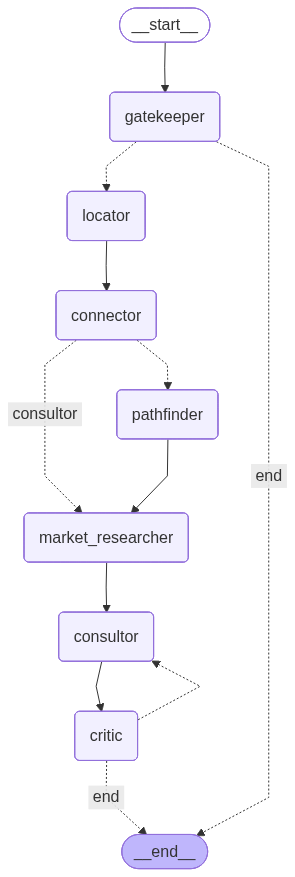

In [10]:
from IPython.display import Image, display

# Display the beautiful LangGraph architecture you just built
try:
    print("🎨 Generating LangGraph Architecture Map...")
    display(Image(talent_app.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"⚠️ Could not generate image: {e}")
    # Fallback to an ASCII text graph if the image API is blocked
    print(talent_app.get_graph().draw_ascii())